## TP Regression Logistique - Classification on Iris Dataset

Durant ce TP, nous allons entrainer et observer les performances de l'algorithme classification Regression Logistique sur le Iris Dataset. 

Ce dataset contient 3 classes de 50 exemples chacune, chaque classe réfère à un type de plante iris. 

Le Iris dstaset contient 4 caractéristiques d'entrée: longueur des sépales , largeur des sépale, longueur des pétales et largeur des pétales.

Objectif de ce TP:

    Observer le fonctionnement de Regression Logistique
    Mesurer les performances de la classification avec Regression Logistique 
    

![Sans%20titre.png](attachment:Sans%20titre.png)

Importons les librairies que nous allons utiliser

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import metrics
import numpy as np

# Partie 1: Importation et exploration des données

Importons le dataset Iris à partir de la librairie scikit-learn. 

In [28]:
# import dataset
iris = datasets.load_iris()

Regardons ce que contient ce dataset

In [29]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Explications:

data: les données sur les fleurs

target: les classes des fleurs

target_names: noms des classes (variables caractéristiques)

feature_names: noms des features (variables caractéristiques)

DESCR: description du dataset

Pour en savoir plus sur le dataset, on affiche DESCR


In [30]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

On affiche les noms des target et des features

In [31]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [32]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [33]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [34]:
print(iris.data.shape)
print(iris.target.shape)

(150, 4)
(150,)


Affichons le nombre d'exemples par classe sous la forme d'un diagramme en bar

<BarContainer object of 3 artists>

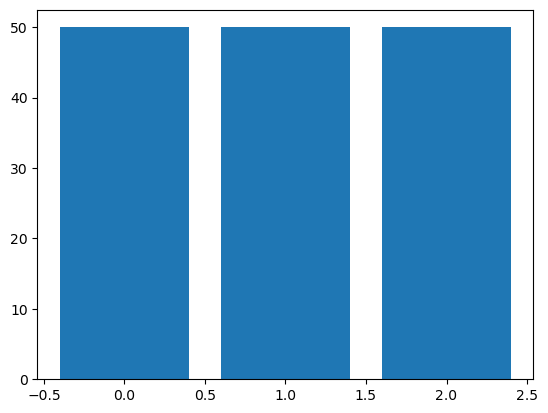

In [35]:
import collections
w=collections.Counter(iris.target)
plt.bar(w.keys(), w.values())

Nous mettons nos données dans un dataframe pandas afin de faciliter leur manipulation:

In [36]:
#creating data frame for pandas
irisdata = pd.DataFrame(iris['data'], columns=iris['feature_names'])

On rajoute une colonne iris_type pour y mettre la classe de chaque fleur

In [37]:
irisdata['iris_type'] = iris.target
irisdata.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Visualisons nos données.

Pour raison de simplicité, nous allons visualiser les classes par rapport à deux caratérsiques seulement.

Commençons par visualiser nos classes par rapport aux deux caractéristiques 'sepal length (cm)' et 'sepal width (cm)'

Text(0, 0.5, 'Sepal width')

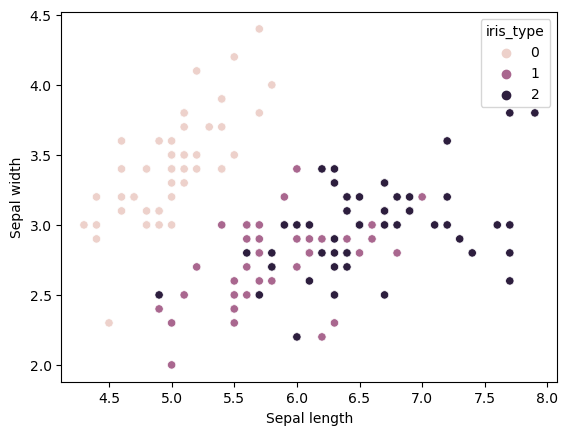

In [38]:
#di= {0: 'Setosa', 1: 'Versicolor', 2:'Virginica'} # dictionary
#irisdata = irisdata.replace({'iris_type': di})
sns.scatterplot(x= irisdata['sepal length (cm)'], y= irisdata['sepal width (cm)'], hue= irisdata['iris_type'])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

et maintenant visualisons par rapport aux deux caractéristiques 'petal length (cm)' et 'petal width (cm)'

Text(0, 0.5, 'petal width')

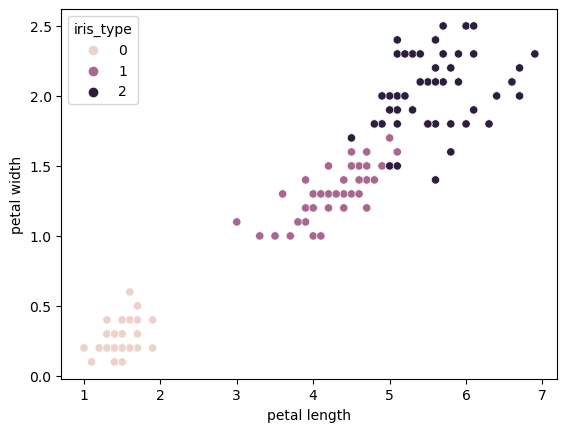

In [39]:
sns.scatterplot(x= irisdata['petal length (cm)'], y= irisdata['petal width (cm)'], hue= irisdata['iris_type'])
plt.xlabel('petal length')
plt.ylabel('petal width')

# Partie 2: Classification Binaire avec l'algorithme de Régression Logistique

## 2.1 Classification Binaire avec deux caractéristiques d'entrée

Dans un premier temps nous considerons uniquement deux classes et ignorons la classe 'virginica'.

Pour un objectif pédagogique , et afin de pouvoir visualiser, considérons uniquement les deux caractéristiques  'sepal length (cm)' et 'sepal width (cm)'.



In [40]:
irisdataBin = irisdata[irisdata['iris_type'] != 2]
irisdataBin.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [41]:
X = irisdataBin[['sepal length (cm)','sepal width (cm)']]
y = irisdataBin['iris_type']

In [42]:
print(X.head(5))
print(y.unique())

   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6
[0 1]


Visualisons nos données

Text(0, 0.5, 'Sepal width')

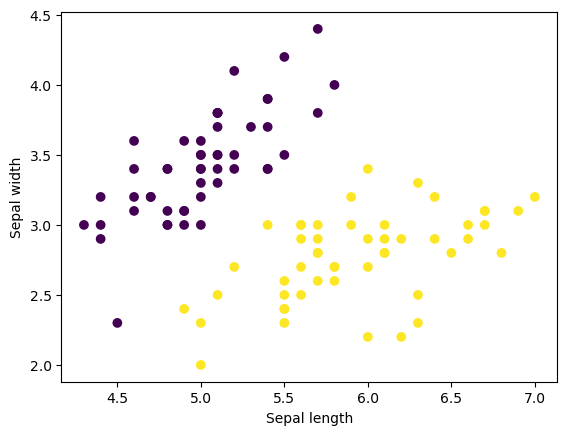

In [43]:
# plot the dataset and color the by class label
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

#### Division des données en train test sets

In [44]:
# Import train_test_split function
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)

Visualisons les données d'entrainement et de Test:

[]

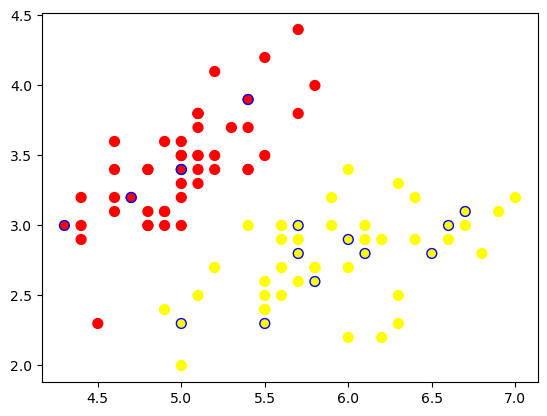

In [45]:
plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train, s=50, cmap='autumn')
plt.scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'], c=y_test,edgecolors='b', s=50, cmap='autumn')
plt.plot()

#### Logistic Regression

Entrainons un modèle de regression logistique pour séparer les deux classes. 

Nous précisons la procédure d'optimisation ('solver'). Ce choix dépend de la tâche que nous demandons à l'algorithme Logistic Regression d'accomplir.

Nous choisissons 'liblinear' qui est adapté aux petits datasets et qui est une variation de l'algorithme Gradient Descendant.

Détails sur les choix de 'solver' et les autres paramètres: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [46]:
from sklearn.linear_model import LogisticRegression
#Create a Logistic Regression Classifier
classifierLR = LogisticRegression(solver='liblinear', random_state=0 )
#Train the model 
classifierLR.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

Observons les prédictions des 5 premiers exemples d'apprentissage

In [47]:
classifierLR.predict_proba(X_train)[:5]

array([[0.79506778, 0.20493222],
       [0.97069605, 0.02930395],
       [0.91638962, 0.08361038],
       [0.97624319, 0.02375681],
       [0.81618797, 0.18381203]])

In [48]:
classifierLR.predict(X_train)[:5]

array([0, 0, 0, 0, 0])

Affichons les coefficient de l'équation de la frontière de décison

In [49]:
classifierLR.intercept_

array([-0.55231639])

In [50]:
classifierLR.coef_

array([[ 2.06833378, -3.46175283]])

L'équation de la frontière de décision est:
-0.55+2.07 sepal_l - 3.46 sepal_w


Par defaut, logistic regression est implémenté dans scikit-learn de sorte à retourner la classe avec la probabilité la plus élevée(threshold = 0.5).

Visualisons la frontière de décision:


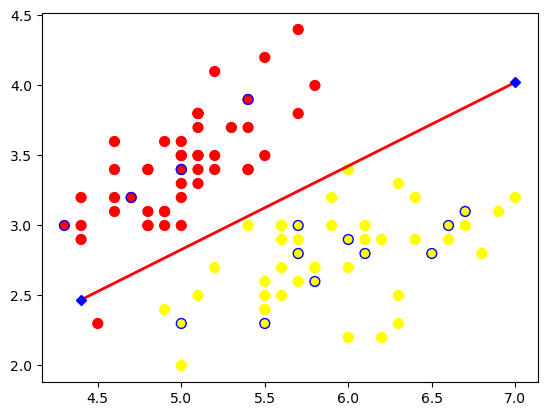

In [51]:
# Retrieve the model parameters.
b = classifierLR.intercept_[0]
w1, w2 = classifierLR.coef_.T
# Calculate the intercept and gradient of the decision boundary.
c = -b/w2
m = -w1/w2

# Plot the data and the classification with the decision boundary.
x1min, x1max = X_train['sepal length (cm)'].min(), X_train['sepal length (cm)'].max()
x2min, x2max = X_train['sepal width (cm)'].min(), X_train['sepal width (cm)'].max()
x1 = np.array([x1min, x1max])
x2 = m*x1 + c


plt.plot(x1, x2, color ='red', linewidth = 2, marker ='D', 
         markersize = 5, markerfacecolor ='blue',
         markeredgecolor ='blue')


plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train, s=50, cmap='autumn')
plt.scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'], c=y_test,edgecolors='b', s=50, cmap='autumn')
plt.plot()

plt.show()


####  Calculons les performances:

1. Afficher la matrice de confusion 
2. Afficher les métriques: Accuracy, Precision, Recall et F1

## 2.2 Classification Binaire avec les deux caractéristiques d'entrée 'petal length (cm)'et 'petal width (cm)'

Refaire le même travail de 3.1 mais avec les charactéristiques d'entrée 'petal length (cm)'et 'petal width (cm)'

Afficher les performances

## 2.3 Classification Binaire avec les deux caractéristiques d'entrée 'sepal length (cm)'et 'sepal width (cm)', mais pour les classes Versicolor et Virginica

Considérer cette fois les charactéristiques d'entrée 'sepal length (cm)'et 'sepal width (cm)' et pour pour les classes Versicolor et Virginica.

Que pouvez vous dire des performances obtenues?

## 2.4 Classification Binaire avec les quatres caractéristiques

Considérer cette fois les quatres charactéristiques d'entrée pour les classes Versicolor et Virginica.

que dire des performances àprès considération des quatres variables caractéristiques?